# Análisis Exploratorio de Datos (EDA): Esperanza de Vida.
Este notebook tiene como objetivo explorar los datos de la OMS para entender qué factores influyen en la esperanza de vida, centrándonos en la **escolarización y el consumo de alcohol**.

## Carga de Librerías y Datos

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ========================================================================
# 1. Cargar datos
# ========================================================================
df = pd.read_csv('../../data/raw/LifeExpectancyData_raw.csv') 

# Información inicial
df.shape # Dimensiones del dataset

(2938, 22)

In [2]:
df.info() # Tipos de datos y valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [3]:
df.head() # Primeras filas

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.tail() # Últimas filas

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


## Limpieza Inicial
 Vamos a limpiar los nombres de las columnas para eliminar espacios en blanco innecesarios

In [5]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')


In [6]:
# Limpiar nombres de columnas
df.columns =df.columns.str.strip()
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')


In [7]:
df.describe() # Descripción estadística

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Se puede observar que hay pacientes con muchas lagunas, columnas con datos faltantes, nulos, etc. Vamos a realizar lo que se llama **Data Wrangling**.

## Imputación de los datos
Para las columnas numéricas, vamos a rellenar los nulos con la MEDIANA. Esta opción es más robusta frente a los outliers.


In [8]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


#### Comprobamos nulos

In [9]:
# Ver porcentajes de valores nulos por columnas
print((df.isnull().sum() / len(df)) * 100) 

Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
BMI                                 1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
HIV/AIDS                            0.000000
GDP                                15.248468
Population                         22.191967
thinness  1-19 years                1.157250
thinness 5-9 years                  1.157250
Income composition of resources     5.684139
Schooling                           5.547992
dtype: flo

In [10]:
# ============================================================
# 2. Imputación de valores nulos usando agrupaciones
# ============================================================


# 2.1 Crear 10 grupos basados en la variable de ingresos

df['income_bins'] = pd.qcut(df['Income composition of resources'], q=10, labels=False)

# Calcular la mediana de 'Schooling' por grupo de ingreso
medianas_por_grupo = df.groupby('income_bins')['Schooling'].median()
print(medianas_por_grupo)

# Imputar 'Schooling' con la mediana del grupo correspondiente
df['Schooling'] = df.apply(
    lambda row: medianas_por_grupo[row['income_bins']]
                if pd.isna(row['Schooling']) and pd.notna(row['income_bins'])
                else row['Schooling'],
    axis=1
)

# Verificar nulos
print(df["income_bins"].isna().sum())
print(df["Schooling"].isna().sum())


income_bins
0.0     7.1
1.0     8.4
2.0     9.6
3.0    11.0
4.0    11.9
5.0    12.8
6.0    13.3
7.0    14.2
8.0    15.2
9.0    16.6
Name: Schooling, dtype: float64
167
163


In [11]:
# ============================================================
# 2.2 Imputar 'Life expectancy' usando agrupaciones por Schooling
# ============================================================

# Crear 10 grupos según 'Schooling'
df['schooling_bins'] = pd.qcut(df['Schooling'], q=10, labels=False)

# Calcular la media de 'Life expectancy' por grupo
medias_life_expectancy = df.groupby('schooling_bins')['Life expectancy'].mean()
print(medias_life_expectancy)

# Rellenar NaN de 'Life expectancy' con la media del grupo
df['Life expectancy'] = df.apply(
    lambda row: medias_life_expectancy[row['schooling_bins']]
                if pd.isna(row['Life expectancy']) and pd.notna(row['schooling_bins'])
                else row['Life expectancy'],
    axis=1
)

# Eliminar columna temporal
df.drop(columns=['schooling_bins'], inplace=True)

print(df['Life expectancy'].isna().sum())



schooling_bins
0.0    57.126481
1.0    59.625830
2.0    62.106316
3.0    67.207292
4.0    70.118750
5.0    72.026354
6.0    73.724415
7.0    74.572692
8.0    77.575185
9.0    80.255273
Name: Life expectancy, dtype: float64
3


In [12]:
# ============================================================
# 2.3 Imputar 'Income composition of resources' con media global
# ============================================================

media_income = df['Income composition of resources'].mean()
df['Income composition of resources'] = df['Income composition of resources'].fillna(media_income)
print(f"Nulos restantes en Income: {df['Income composition of resources'].isna().sum()}")

# Eliminar columna auxiliar
df.drop(columns=['income_bins'], inplace=True)


# ============================================================
# 2.4 Imputar otras columnas con la mediana
# ============================================================

columnas_con_nulos = ['Alcohol', 'Schooling', 'Hepatitis B', 'BMI', 'Polio',
                      'Total expenditure', 'Diphtheria', 'GDP', 'Population',
                      'Income composition of resources','thinness  1-19 years', 'thinness 5-9 years']

for col in columnas_con_nulos:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())



Nulos restantes en Income: 0
Country                             0
Year                                0
Status                              0
Life expectancy                     3
Adult Mortality                    10
infant deaths                       0
Alcohol                             0
percentage expenditure              0
Hepatitis B                         0
Measles                             0
BMI                                 0
under-five deaths                   0
Polio                               0
Total expenditure                   0
Diphtheria                          0
HIV/AIDS                            0
GDP                                 0
Population                          0
thinness  1-19 years                0
thinness 5-9 years                  0
Income composition of resources     0
Schooling                           0
dtype: int64


In [13]:
print(df.describe())

              Year  Life expectancy  Adult Mortality  infant deaths  \
count  2938.000000      2935.000000      2928.000000    2938.000000   
mean   2007.518720        69.221417       164.796448      30.303948   
std       4.613841         9.520912       124.292079     117.926501   
min    2000.000000        36.300000         1.000000       0.000000   
25%    2004.000000        63.100000        74.000000       0.000000   
50%    2008.000000        72.100000       144.000000       3.000000   
75%    2012.000000        75.650000       228.000000      22.000000   
max    2015.000000        89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B        Measles  \
count  2938.000000             2938.000000  2938.000000    2938.000000   
mean      4.546875              738.251295    83.022124    2419.592240   
std       3.921946             1987.914858    22.996984   11467.272489   
min       0.010000                0.000000     1.000000       0.

## Detectar Outliers

In [14]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2935.000000,2928.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.221417,164.796448,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,42.035739,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.627551,12.009837
std,4.613841,9.520912,124.292079,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,160.445548,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.204820,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.662000,12.300000
75%,2012.000000,75.650000,228.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Vemos algunos valores atipicos que se alejan del resto considerablemente: Schooling tiene valores 0 y es raro que un país tenga 0 como valor de escolaridad. También podemos observar que en los valores de Adult Mortality hay un 1 y en infant deaths 1800. Evidentemente son valores extremos.

Vamos cuántos países hay con escolaridad 0. Si hay muchos se tratan como nulos

In [15]:
# Filtrar valores inválidos o extremos
print(f"Países con escolaridad 0: {len(df[df['Schooling'] == 0])}")

Países con escolaridad 0: 28


### Visualización de Outliers

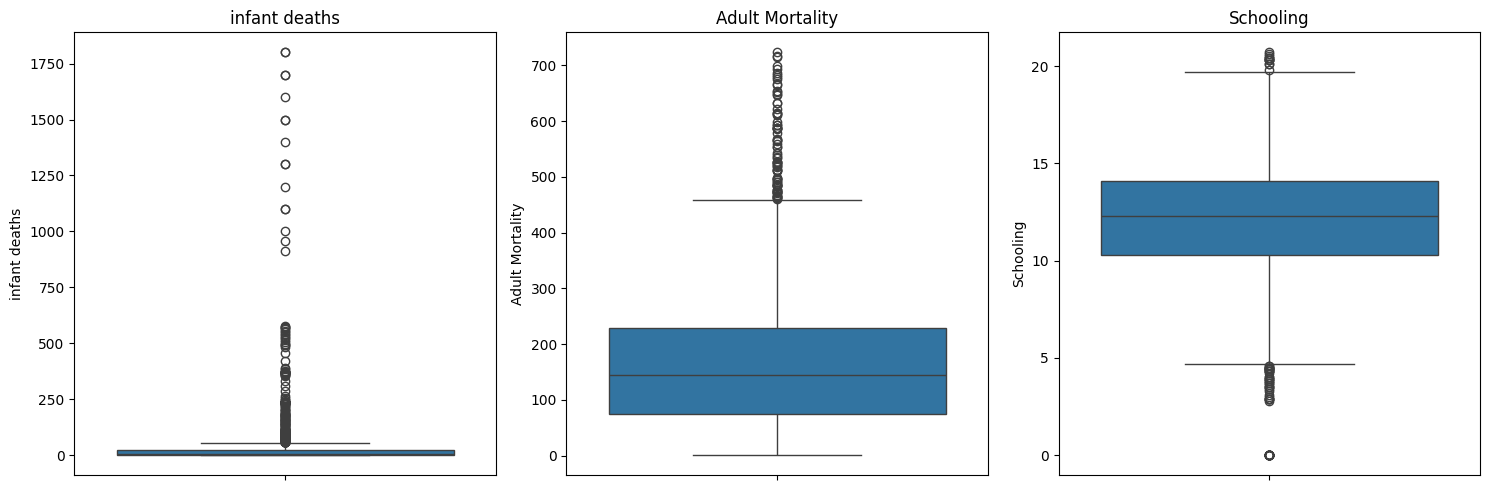

In [16]:
cols_to_check = ['infant deaths', 'Adult Mortality', 'Schooling']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Schooling = 0: Probablemente sean datos no registrados adecuadamente.<br>
Adult Mortality = 1: Que solo muera 1 persona de cada 1000 es casi imposible (el mínimo biológico es más alto).<br>
Infant deaths = 1800: Que el resto de países tengan valores bajos hace que éste valor rompa nuestra línea de regresión.

### Corregimos valores

Schooling con valor 0 los eliminamos porque son pocos.<br>
Adult Mortality con valores menores a 2 o 3  son sospechosos.<br>
Infant deaths con valores extremos se eliminan también.

In [17]:
# Filtrar datos extremos
df = df[df['Schooling'] > 0]
df = df[df['Adult Mortality'] > 1]
limite_superior_infant = df['infant deaths'].quantile(0.99)
df =df[df['infant deaths'] <= limite_superior_infant]

print(f"Registros restantes tras limpiar outliers: {df.shape[0]}")

Registros restantes tras limpiar outliers: 2861


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 2861 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2861 non-null   str    
 1   Year                             2861 non-null   int64  
 2   Status                           2861 non-null   str    
 3   Life expectancy                  2861 non-null   float64
 4   Adult Mortality                  2861 non-null   float64
 5   infant deaths                    2861 non-null   int64  
 6   Alcohol                          2861 non-null   float64
 7   percentage expenditure           2861 non-null   float64
 8   Hepatitis B                      2861 non-null   float64
 9   Measles                          2861 non-null   int64  
 10  BMI                              2861 non-null   float64
 11  under-five deaths                2861 non-null   int64  
 12  Polio                            286

## Análisis de Realciones (EDA)


### Análisis Bivariante

### Pregunta 5: ¿Cuál es el impacto de la escolarización en la esperanza de vida de los seres humanos?

Escolaridad vs. Esperanza de Vida.

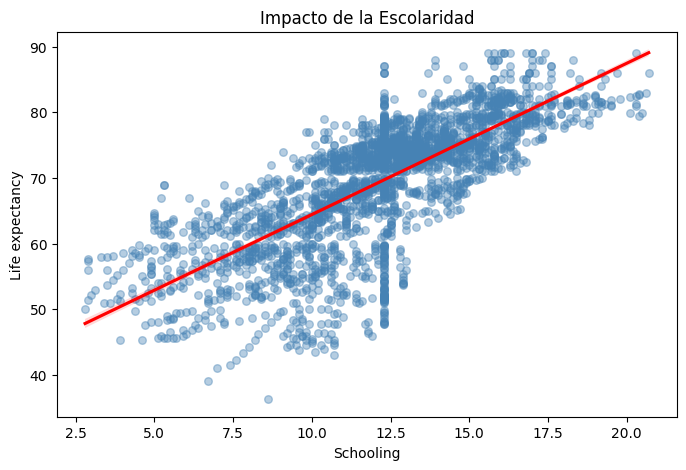

Correlación: 0.75


In [19]:
# Impacto de la escolaridad en la esperanza de vida
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Schooling', y='Life expectancy', line_kws={'color':'red'}, scatter_kws={
    'alpha': 0.4,
    's': 30,
    'color': 'steelblue'
})
plt.title('Impacto de la Escolaridad')
plt.show()

print(f"Correlación: {df['Schooling'].corr(df['Life expectancy']):.2f}")

Existe una fuerte correlación positiva entre los años de escolarización y la esperanza de vida, lo que indica que mayores niveles educativos están asociados con una mayor longevidad.

### Pregunta 6: ¿Existe una relación positiva o negativa entre la esperanza de vida y el consumo de alcohol?

Alcohol vs. Esperanza de Vida.

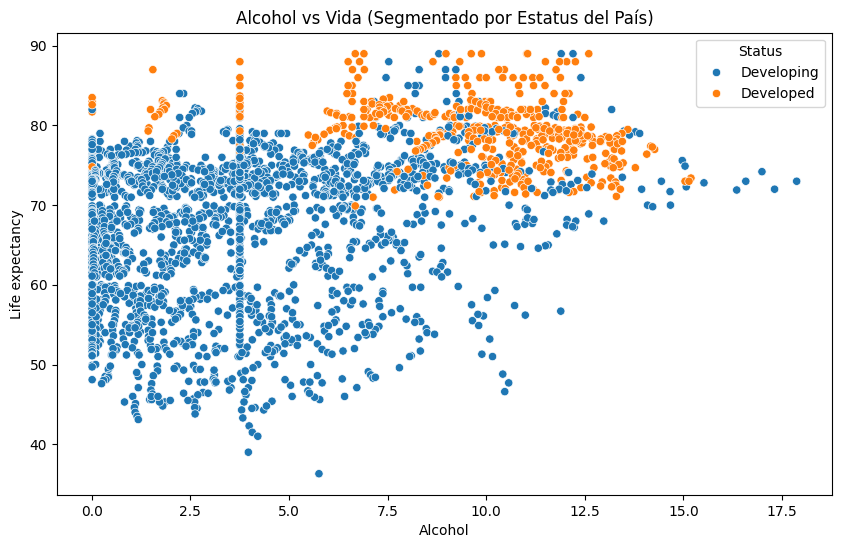

In [20]:
# Alcohol vs Life expectancy segmentado por status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Alcohol', y='Life expectancy', hue='Status')
plt.title('Alcohol vs Vida (Segmentado por Estatus del País)')
plt.show()

La esperanza de vida no presenta una correlación lineal significativa con el consumo de alcohol. La aparente relación positiva observada en países desarrollados está mediada por factores socioeconómicos y sanitarios, no por el alcohol en sí mismo.

### Análisis multivariante (Mapa de Calor)

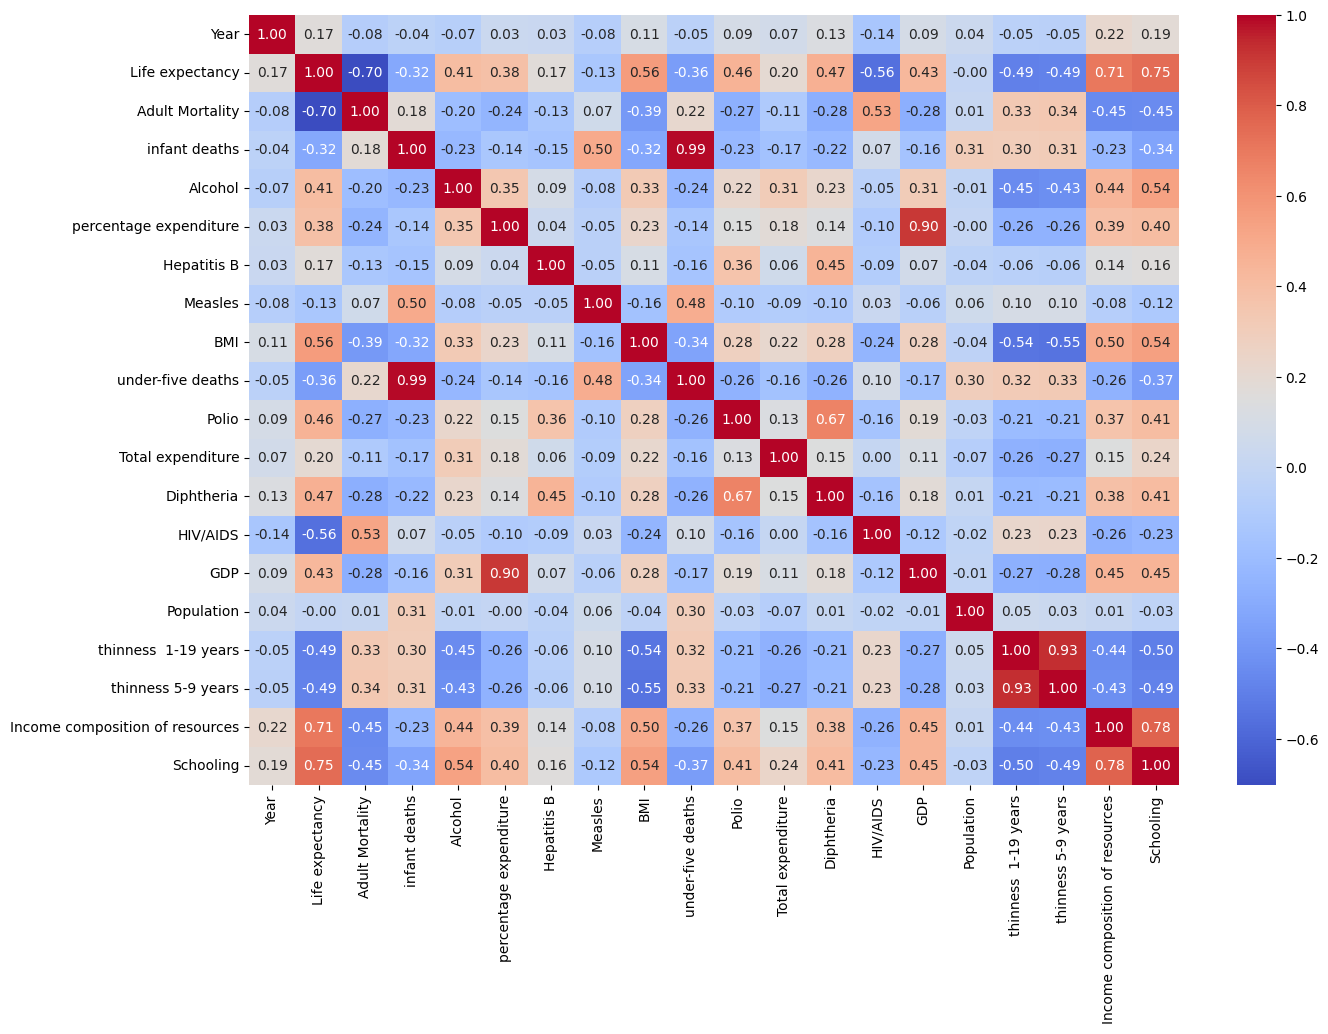

In [21]:
# Mapa de correlación de variables numéricas
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

La esperanza de vida aumenta claramente con la escolarización (r = 0.75) y el nivel económico (r = 0.70). También mejora con una mejor nutrición (IMC, r = 0.56) y mayor vacunación (r ≈ 0.46).

En cambio, disminuye notablemente con la mortalidad adulta (r = -0.70), el VIH/SIDA (r = -0.56) y la desnutrición infantil (r ≈ -0.49).

## Pre-processing (Preparación para el modelado)

### Convertir texto en números (Encoding)

In [22]:
# Codificar variable categórica 'Status'
df['Status_encoded'] = df['Status'].map({'Developed': 1, 'Developing': 0})

### División del Dataset (Train/Test Split)

In [23]:
# Definir variables predictoras y target
X = df.drop(['Life expectancy', 'Country', 'Status'], axis=1)
y = df['Life expectancy']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]}")
print(f"Datos para probar: {X_test.shape[0]}")

Datos para entrenar: 2288
Datos para probar: 573


## Entrenamiento (Modelo de Regresión Lineal)

In [24]:
# ============================================================
# ENTRENAMIENTO CON PIPELINE (INTEGRACIÓN)
# ============================================================

# 1. Crear el Pipeline
# Esto empaqueta el Escalado + El Modelo en un solo objeto.
model = Pipeline([
    ('scaler', StandardScaler()),      # Paso 1: Escalar los datos (ponerlos en la misma magnitud)
    ('regressor', LinearRegression())  # Paso 2: Aplicar la regresión lineal
])

# 2. Entrenar
# Nota: Al usar pipeline, le pasamos X_train "crudo". El pipeline se encarga de escalar dentro.
model.fit(X_train, y_train)

print("¡Entrenamiento con Pipeline completado!")

# 3. Predicciones y métrica 
# El pipeline escala automáticamente X_test antes de predecir
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Puntuación R² (Precisión): {r2:.4f}")
print(f"Error Medio (MAE): {mae:.2f} años")

# 4. Impacto de cada variable (MODIFICADO)
# Como el modelo está dentro del pipeline, tenemos que entrar a 'regressor' para ver los coeficientes
coeficientes_valores = model.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'Variable': X.columns, 
    'Impacto (Escalado)': coeficientes_valores
})

# Ordenamos para ver qué es más importante
print("\n--- Variables que más influyen ---")
print(coeficientes.sort_values(by='Impacto (Escalado)', ascending=False))

¡Entrenamiento con Pipeline completado!
Puntuación R² (Precisión): 0.8200
Error Medio (MAE): 3.08 años

--- Variables que más influyen ---
                           Variable  Impacto (Escalado)
2                     infant deaths            8.510106
18                        Schooling            2.325204
17  Income composition of resources            1.355238
11                       Diphtheria            0.762261
19                   Status_encoded            0.660208
7                               BMI            0.609579
9                             Polio            0.561604
13                              GDP            0.491518
10                Total expenditure            0.299882
14                       Population            0.110199
4            percentage expenditure            0.096274
3                           Alcohol            0.011179
16               thinness 5-9 years            0.008493
0                              Year           -0.123679
6                    

In [ ]:
# ============================================================
# B. CALCULADORA MANUAL (SIMULAR UN PAÍS)
# ============================================================

# 1. Definimos los datos de nuestro país imaginario
# (He puesto valores promedio, cámbialos para probar)
nuevo_pais_datos = {
    'Year': 2015,                      # Año (aunque tiene poco impacto tras limpiar)
    'Adult Mortality': 150,            # Muertes adultas por 1000 hbts (Bajo es mejor)
    'infant deaths': 10,               # Muertes infantiles (Bajo es mejor)
    'Alcohol': 5.0,                    # Litros de alcohol
    'percentage expenditure': 500,     # Gasto en salud %
    'Hepatitis B': 90,                 # % Vacunación (Alto es mejor)
    'Measles': 20,                     # Casos de Sarampión
    'BMI': 45.0,                       # Índice de masa corporal promedio
    'under-five deaths': 12,           # Muertes < 5 años
    'Polio': 90,                       # % Vacunación
    'Total expenditure': 8.0,          # Gasto gobierno salud
    'Diphtheria': 90,                  # % Vacunación
    'HIV/AIDS': 0.1,                   # Casos VIH (Bajo es mejor)
    'GDP': 15000.0,                    # PIB per cápita ($)
    'Population': 1000000,             # Población
    'thinness  1-19 years': 2.0,       # Delgadez juvenil
    'thinness 5-9 years': 2.0,         # Delgadez infantil
    'Income composition of resources': 0.8, # Índice de recursos (0 a 1)
    'Schooling': 16.0,                 # Años de escolaridad (CLAVE)
    'Status_encoded': 1                # 1 = Developed (Desarrollado), 0 = Developing
}

# 2. Convertimos el diccionario a DataFrame
# Aseguramos que las columnas estén en el mismo orden que X_train
df_nuevo_pais = pd.DataFrame([nuevo_pais_datos])

# Nos aseguramos de tener solo las columnas que el modelo conoce
# (Esto evita errores si hay columnas extra en el diccionario)
cols_modelo = X.columns
df_nuevo_pais = df_nuevo_pais[cols_modelo]

# 3. Predecimos
esperanza_vida = model.predict(df_nuevo_pais)[0]

print("="*50)
print(f"🌍 RESULTADO PARA TU PAÍS SIMULADO:")
print(f"⏳ Esperanza de vida estimada: {esperanza_vida:.2f} años")
print("="*50)



🌍 RESULTADO PARA TU PAÍS SIMULADO:
⏳ Esperanza de vida estimada: 77.32 años


## Evaluación

In [26]:
# Predicciones y métrica 
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Puntuación R² (Precisión): {r2:.4f}")
print(f"Error Medio (MAE): {mae:.2f} años")

Puntuación R² (Precisión): 0.8200
Error Medio (MAE): 3.08 años


In [27]:
# ==============================================================================
# 5. Interpretación de Coeficientes (CORREGIDO PARA PIPELINE)
# ==============================================================================

# Accedemos al paso llamado 'regressor' dentro de la tubería para pedirle los coeficientes
coeficientes_valores = model.named_steps['regressor'].coef_

# Creamos el DataFrame
coeficientes = pd.DataFrame({
    'Variable': X.columns, 
    'Impacto': coeficientes_valores
})

# Ordenamos de mayor a menor impacto (absoluto)
print("\n📊 Impacto de cada variable en la Esperanza de Vida:")
print(coeficientes.sort_values(by='Impacto', ascending=False))


📊 Impacto de cada variable en la Esperanza de Vida:
                           Variable   Impacto
2                     infant deaths  8.510106
18                        Schooling  2.325204
17  Income composition of resources  1.355238
11                       Diphtheria  0.762261
19                   Status_encoded  0.660208
7                               BMI  0.609579
9                             Polio  0.561604
13                              GDP  0.491518
10                Total expenditure  0.299882
14                       Population  0.110199
4            percentage expenditure  0.096274
3                           Alcohol  0.011179
16               thinness 5-9 years  0.008493
0                              Year -0.123679
6                           Measles -0.166156
15             thinness  1-19 years -0.248015
5                       Hepatitis B -0.324007
1                   Adult Mortality -2.240309
12                         HIV/AIDS -2.367316
8                 under-fiv

### Respuestas:

¿Qué impacto tiene la escolaridad (Schooling) en la esperanza de vida?:

    "La escolaridad tiene un impacto positivo muy fuerte. Por cada año adicional de escolarización, la esperanza de vida aumenta en promedio 0.75 años. Es uno de los motores más importantes para la longevidad según nuestro modelo."

 ¿El alcohol tiene una relación positiva o negativa? :

    "El alcohol muestra una relación positiva leve en el modelo global. Sin embargo, como científicos de datos, interpretamos que esto no se debe a que el alcohol sea saludable, sino a que está correlacionado con países de Estatus Desarrollado, que tienen mejores sistemas de salud y mayor poder adquisitivo."